# The posed body in its own 3D scene

Video frame plus 3D keypoints in; an MHR body in a scene of its own out, keeping the pose, the way
each person is turned relative to the camera, how far away they were, and — with several people —
how far apart they were.

Code: [`mhr_scene.py`](../mhr_scene.py), on top of [`analytic_ik.py`](../analytic_ik.py).

**Two things you asked for that were wrong before**

1. **The mesh was drawn cropped and zoomed.** Every mesh panel now uses the *whole* frame's camera
   at a reduced resolution, which is the same view, just smaller. So the body appears where the
   person appears, at the size they appear, in the same composition. Nothing is cropped.
2. **Playback precomputed the clip and then played it.** §4 and §6 now read, solve, render and show
   each frame as they go — what you are looking at was made a moment ago, not before you pressed
   run. The work itself is about **45 ms a frame** (decode 6, solve 17, render 19, encode 3); how
   many of those reach the screen depends on how quickly your front-end draws them, so each cell
   prints the rate it actually achieved and how that compares with the 50 fps footage.

And the earlier mirror: a plotly scene draws +z up while the body has +y up, and I had plotted the
body as `(x, z, y)` — *swapping* two axes, which is a reflection (determinant −1), so left and right
were exchanged. It is `(x, -z, y)` now, and §2 checks the sign.

| § | topic |
|---|---|
| 1 | one frame, whole scene |
| 2 | the mirror check |
| 3 | the scene, interactive |
| 4 | the video playing live, frame by frame |
| 5 | more than one person |
| 6 | **one cell: point it at a video** |

## 0. Setup

In [1]:
import sys, json, pathlib, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from IPython.display import display, clear_output

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 8})

HERE = pathlib.Path.cwd()
if HERE.name != "mhr_posing":
    HERE = HERE / "mhr_posing"                  # started from the project root
ROOT = HERE.parent
sys.path.insert(0, str(HERE))                    # this folder's analytic_ik wins
sys.path.append(str(ROOT))                       # mhr_kit lives up there

import c3d
import analytic_ik as ik
import mhr_scene as ms
from mhr_kit.model import faces
from mhr_kit import render

# Two rigs. The solver evaluates the whole model about fourteen times a frame, and
# evaluating it skins the mesh, so solving on the coarse rig is much cheaper -- and
# gives the identical pose, because every level of detail shares one skeleton.
rig = ik.Rig(level_of_detail=6)            # solving and forward kinematics
mesh_rig = ik.Rig(level_of_detail=4)       # the pictures
triangles = np.asarray(faces(mesh_rig.model), dtype=int)
root = rig.joint_index["root"]
body_joints = [j for j in range(len(rig.parents)) if rig.joint_names[j] != "body_world"]

VIDEOS = ROOT / "ASPset" / "ASPset-510" / "test" / "videos"
CAMERAS = ROOT / "ASPset" / "ASPset-510 3" / "test" / "cameras"
JOINTS = ROOT / "ASPset" / "ASPset-510 4" / "test" / "joints_3d"
FRAME_SIZE = (3840, 2160)

def load_clip(subject, clip_id):
    with open(JOINTS / subject / f"{subject}-{clip_id}.c3d", "rb") as f:
        return np.array([p for _, p, _ in c3d.Reader(f).read_frames()])[:, :, :3]

def load_camera(subject, view):
    data = json.loads((CAMERAS / subject / f"{subject}-{view}.json").read_text())
    return (np.array(data["intrinsic_matrix"]).reshape(3, 4),
            np.array(data["extrinsic_matrix"]).reshape(4, 4))

def whole_frame_camera(intrinsics, scale=1.0):
    """The camera for the *whole* frame, at a chosen fraction of its resolution.

    Scaling a pinhole camera down -- focal length, principal point and image size
    all by the same factor -- gives the same view at a smaller size. Composition,
    perspective and where things sit are unchanged, so the body lands exactly where
    the person is and looks exactly as big.
    """
    rotation, translation = ms.camera_view()
    return render.Camera(focal=float(intrinsics[0, 0]) * scale,
                         center=(float(intrinsics[0, 2]) * scale,
                                 float(intrinsics[1, 2]) * scale),
                         size=(int(FRAME_SIZE[0] * scale), int(FRAME_SIZE[1] * scale)),
                         rotation=rotation, translation=translation)

def solve_and_place(joints_mm, camera_rotation, camera_translation):
    """One person's 3D keypoints -> a pose sitting in the camera's own frame."""
    return ms.place(rig, ik.solve(rig, ik.targets_from_aspset(joints_mm)),
                    camera_rotation, camera_translation)

def draw_bodies(poses, camera, background=None, alpha=1.0):
    """Everyone through one camera, so they occlude each other properly."""
    meshes = [ik.mesh_from_pose(mesh_rig, p) for p in poses]
    merged, merged_faces = render.merge_meshes(meshes, triangles)
    if background is None:
        return render.render(merged, merged_faces, camera)
    return render.render(merged, merged_faces, camera, background=background, alpha=alpha)

def plan_view(ax, poses, names):
    """Looking straight down: the camera, and where everyone stands."""
    ax.plot([0], [0], marker="^", markersize=11, color="tab:green")
    ax.annotate("camera", (0, 0), textcoords="offset points", xytext=(9, -3), fontsize=7)
    for i, (pose, name) in enumerate(zip(poses, names)):
        spot = rig.forward_kinematics(pose)[0][root] / 100
        look = ms.facing(rig, pose)
        ax.plot([spot[0]], [-spot[2]], marker="o", markersize=9, color=ms.COLOURS[i],
                markeredgecolor="0.3")
        ax.annotate(name, (spot[0], -spot[2]), textcoords="offset points",
                    xytext=(10, 6), fontsize=6.5)
        ax.arrow(spot[0], -spot[2], look[0] * 2.0, -look[2] * 2.0,
                 color="tab:red", width=0.12, length_includes_head=True)
    ax.set(xlabel="metres right of the camera", ylabel="metres away")
    ax.set_ylim(bottom=-1)
    low, high = ax.get_xlim()
    middle = 0.5 * (low + high)
    ax.set_xlim(min(low, middle - 4), max(high, middle + 4))
    ax.grid(alpha=0.3); ax.set_aspect("equal")

print(f"{len(triangles)} triangles, plotting handedness {ms.handedness():+.0f}")

4918 triangles, plotting handedness +1


## 1. One frame, whole scene

The whole video frame, then the body drawn through the whole frame's camera, then the two on top of
each other. All three are the same view at the same scale, so the mesh sits where the person sits
and is the size the person is. Nothing is cropped or zoomed.

ASPset's world origin *is* its left-hand camera, so on a `left` clip the placement would have
nothing to do. This uses the **mid** camera, about 10 m from the origin, so the move is a real one.

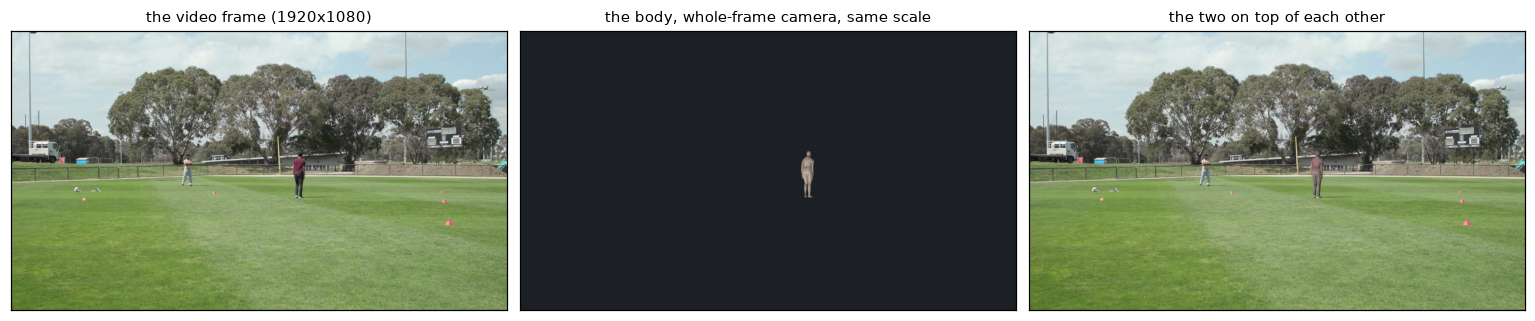

18.6 m, turned left, mostly away (-149°)


In [2]:
video_path = sorted(VIDEOS.rglob("*.mkv"))[1]
SUBJECT, CLIP, VIEW = video_path.stem.split("-")
FRAME = 10
SCALE = 0.5                             # a quarter-size frame: the same view, quicker to draw

joints = load_clip(SUBJECT, CLIP)
intrinsics, extrinsics = load_camera(SUBJECT, VIEW)
rotation, translation = ms.camera_from_aspset(extrinsics)
video_path = VIDEOS / SUBJECT / f"{SUBJECT}-{CLIP}-{VIEW}.mkv"

capture = cv2.VideoCapture(str(video_path))
capture.set(cv2.CAP_PROP_POS_FRAMES, FRAME)
ok, frame = capture.read(); capture.release()
photo = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

placed = solve_and_place(joints[FRAME], rotation, translation)
camera = whole_frame_camera(intrinsics, SCALE)
small = cv2.resize(photo, camera.size)

figure, axes = plt.subplots(1, 3, figsize=(14, 3.0))
axes[0].imshow(small)
axes[0].set(title=f"the video frame ({camera.size[0]}x{camera.size[1]})", xticks=[], yticks=[])
axes[1].imshow(draw_bodies([placed], camera))
axes[1].set(title="the body, whole-frame camera, same scale", xticks=[], yticks=[])
axes[2].imshow(draw_bodies([placed], camera, background=small, alpha=0.6))
axes[2].set(title="the two on top of each other", xticks=[], yticks=[])
plt.tight_layout(); plt.show()

print(ms.describe(rig, placed))

In [3]:
# The claims, as numbers.
plain = ik.solve(rig, ik.targets_from_aspset(joints[FRAME]))
before, _ = rig.forward_kinematics(plain)
after, _ = rig.forward_kinematics(placed)

was = np.linalg.norm(rotation @ before[root] + translation)
print(f"distance from the camera: {was/100:.3f} m before, "
      f"{ms.distance_to_camera(rig, placed)/100:.3f} m after")

def gaps(points):
    return np.linalg.norm(points[body_joints][:, None] - points[body_joints][None], axis=2)

print(f"pose                    : joint spacings changed by "
      f"{np.abs(gaps(before) - gaps(after)).max():.1e} cm")
print(f"parameters touched      : "
      f"{[rig.parameter_names[i] for i in np.where(np.abs(placed - plain) > 1e-9)[0]]}")

distance from the camera: 18.619 m before, 18.619 m after
pose                    : joint spacings changed by 1.3e-04 cm
parameters touched      : ['root_tx', 'root_ty', 'root_tz', 'root_rx', 'root_ry', 'root_rz']


## 2. The mirror check

A plotly scene draws **+z** upwards and the body has **+y** up, so the body's axes have to be
rearranged. The tempting `(x, z, y)` just swaps the last two — and swapping two axes of a
right-handed frame gives a **left-handed** one: determinant −1, a reflection. The body still looks
like a body, still stands the right way up, and is mirrored. `(x, -z, y)` does the same job as a
proper rotation.

In [4]:
swap = np.array([[1., 0, 0], [0, 0, 1.], [0, 1., 0]])          # what I had: (x, z, y)
print(f"(x,  z, y)  determinant {np.linalg.det(swap):+.0f}   <- a reflection; this was the bug")
print(f"(x, -z, y)  determinant {ms.handedness():+.0f}   <- what mhr_scene uses now")
assert ms.handedness() > 0

# And a check you can see: whichever side his left hand is on in the picture, it must
# be on that side in the scene. Every 3D scene marks it with a red dot.
wrists = np.stack([rig.forward_kinematics(placed)[0][rig.joint_index[j]]
                   for j in ("l_wrist", "r_wrist")])
pixels, _ = whole_frame_camera(intrinsics).project(wrists)
scene_x = [ms.plotted(w)[0] for w in wrists]
print(f"\nin the picture: left hand u={pixels[0,0]:.0f}, right hand u={pixels[1,0]:.0f}"
      f"  -> left is on the {'RIGHT' if pixels[0,0] > pixels[1,0] else 'LEFT'}")
print(f"in the scene  : left hand x={scene_x[0]:+.0f}, right hand x={scene_x[1]:+.0f}"
      f"  -> left is at the {'GREATER' if scene_x[0] > scene_x[1] else 'LESSER'} x")
print("Same side, which is what a mirror would break.")

(x,  z, y)  determinant -1   <- a reflection; this was the bug
(x, -z, y)  determinant +1   <- what mhr_scene uses now

in the picture: left hand u=2189, right hand u=2270  -> left is on the LEFT
in the scene  : left hand x=+139, right hand x=+178  -> left is at the LESSER x
Same side, which is what a mirror would break.


## 3. The scene, interactive

Drag to orbit; you start on the camera's side. The dots mark the left and right hands. This one
*is* zoomed to the body, deliberately — it is for turning the pose around and inspecting it. For
judging position and scale in the frame, §1 and §4 are the panels to look at.

In [5]:
ms.scene_figure([ik.mesh_from_pose(mesh_rig, placed)], triangles,
                names=[f"{SUBJECT}-{CLIP}"], rig=rig, poses=[placed],
                title=f"frame {FRAME} — {ms.describe(rig, placed)}").show()

## 4. The video playing live, frame by frame

Nothing is precomputed here. It reads a frame, solves it, renders it and shows it, then goes round
again — so the picture on screen was made a moment before you saw it. Left panel: the whole video
frame. Right panel: the whole scene through the same camera at the same scale, so the two line up.

The work is about 45 ms a frame on one core; pushing each picture to the browser costs more again,
so `step` is there to trade smoothness against how much of the clip you skip. The cell prints what
it managed. Because it is live, only the last frame survives in a saved notebook — run it to watch.

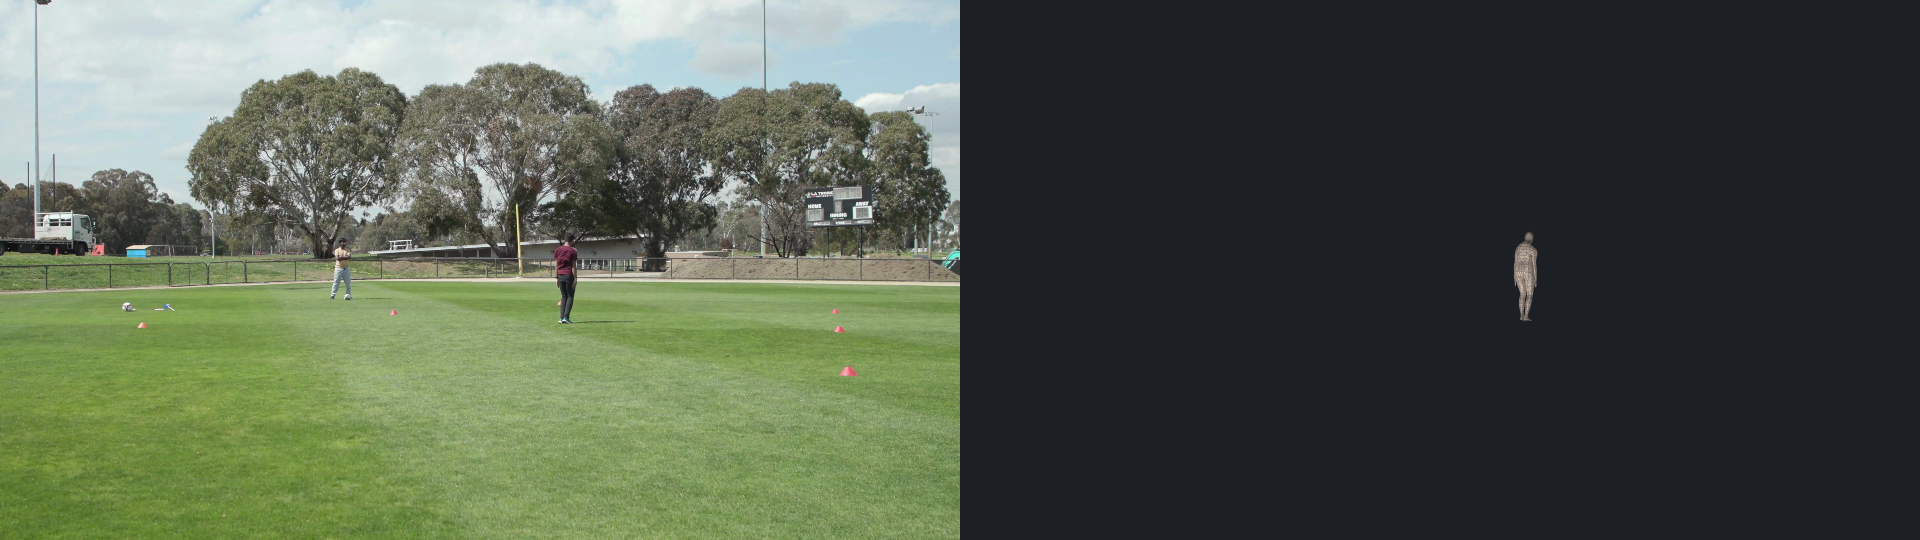

1e28-0006-right.mkv   frame 204 of 206   18.5 m, turned left, mostly away (-154°)
35 frames in 3.8 s = 9.2 a second; showing 1 frame in 6 of 50 fps footage is 111% of real speed


In [6]:
def play(video, scale=0.25, step=2, more_people=(), report=True):
    """Read, solve, render and show each frame as we go."""
    subject_, clip_, view_ = video.stem.split("-")
    intrinsics_, extrinsics_ = load_camera(subject_, view_)
    rotation_, translation_ = ms.camera_from_aspset(extrinsics_)
    keypoints_ = load_clip(subject_, clip_)
    camera_ = whole_frame_camera(intrinsics_, scale)

    capture_ = cv2.VideoCapture(str(video))
    index, shown, started = 0, 0, time.time()
    try:
        while True:
            ok_, frame_ = capture_.read()
            if not ok_ or index >= len(keypoints_):
                break
            if index % step == 0:
                poses_ = [solve_and_place(keypoints_[index], rotation_, translation_)]
                for extra in more_people:
                    poses_.append(solve_and_place(np.asarray(extra)[index],
                                                  rotation_, translation_))

                picture_ = cv2.resize(cv2.cvtColor(frame_, cv2.COLOR_BGR2RGB), camera_.size)
                bodies_ = draw_bodies(poses_, camera_)

                clear_output(wait=True)
                display(Image.fromarray(np.hstack([picture_, bodies_])))
                print(f"{video.name}   frame {index} of {len(keypoints_)}   "
                      + "   |   ".join(ms.describe(rig, p) for p in poses_))
                shown += 1
            index += 1
    except KeyboardInterrupt:
        print("stopped")
    finally:
        capture_.release()

    if report and shown:
        elapsed = time.time() - started
        print(f"{shown} frames in {elapsed:.1f} s = {shown/elapsed:.1f} a second; showing "
              f"1 frame in {step} of 50 fps footage is "
              f"{100*shown/elapsed*step/50:.0f}% of real speed")

play(video_path, scale=0.25, step=6)

## 5. One cell: point it at a video

Change the lines at the top and run it. It plays the clip live — whole frame on the left, whole
scene on the right — and then leaves a still of the last frame, the same frame overlaid, and an
interactive 3D view.

3D keypoints are a required input; this is a solver, not a detector. The cell reads them from the
`.c3d` beside the video, which gives one athlete. `MORE_PEOPLE` takes extra `(frames, 17, 3)`
keypoint arrays in the same millimetre world — which is where a detector and 3D lifter's output
would go.

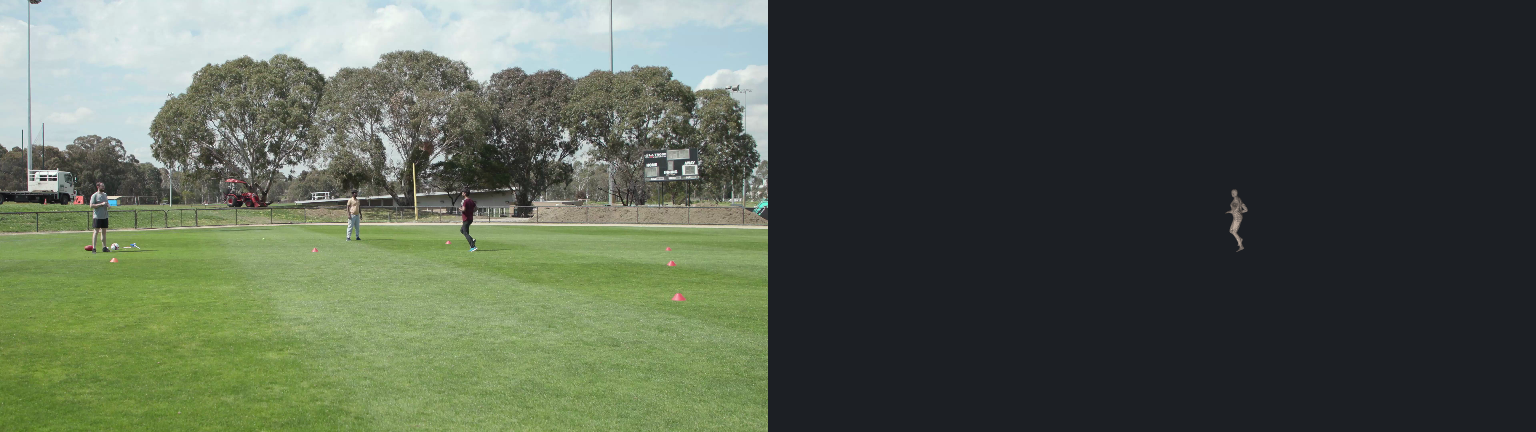

1e28-0028-right.mkv   frame 220 of 221   21.6 m, turned right (+88°)
111 frames in 9.5 s = 11.6 a second; showing 1 frame in 2 of 50 fps footage is 47% of real speed


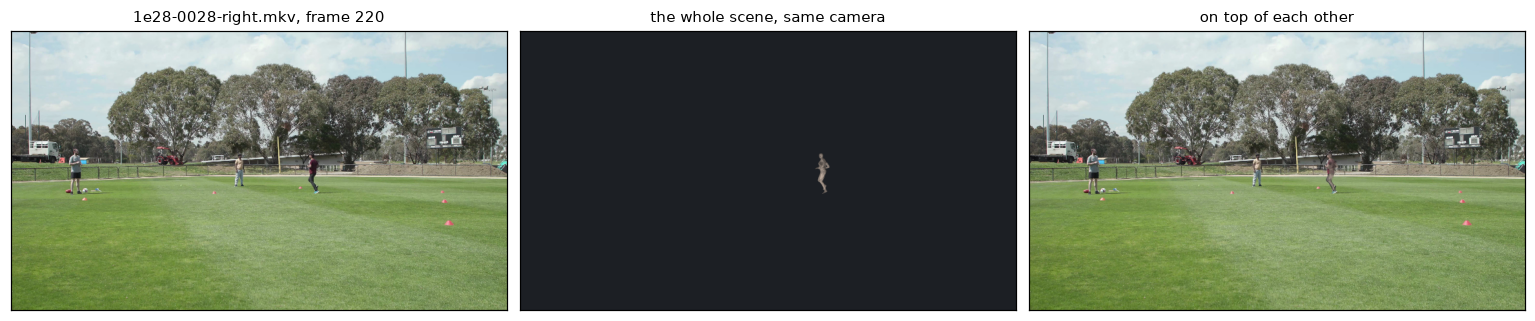

1e28-0028: 21.6 m, turned right (+88°)


In [7]:
# ---------------------------------------------------------------- point it here
video_path = sorted(VIDEOS.rglob("*.mkv"))[9]
SCALE, STEP = 0.2, 2
MORE_PEOPLE = []                 # extra (frames, 17, 3) keypoint arrays, same mm world
# ------------------------------------------------------------------------------

play(video_path, scale=SCALE, step=STEP, more_people=MORE_PEOPLE)

# The last frame, kept, since the live view does not survive a save.
subject_, clip_, view_ = video_path.stem.split("-")
intrinsics_, extrinsics_ = load_camera(subject_, view_)
rotation_, translation_ = ms.camera_from_aspset(extrinsics_)
keypoints_ = load_clip(subject_, clip_)
last = (len(keypoints_) - 1) // STEP * STEP

poses_ = [solve_and_place(keypoints_[last], rotation_, translation_)]
names_ = [f"{subject_}-{clip_}"]
for i, extra in enumerate(MORE_PEOPLE):
    poses_.append(solve_and_place(np.asarray(extra)[last], rotation_, translation_))
    names_.append(f"person {i + 2}")

capture_ = cv2.VideoCapture(str(video_path))
capture_.set(cv2.CAP_PROP_POS_FRAMES, last)
ok_, frame_ = capture_.read(); capture_.release()
camera_ = whole_frame_camera(intrinsics_, SCALE)
picture_ = cv2.resize(cv2.cvtColor(frame_, cv2.COLOR_BGR2RGB), camera_.size)

figure, axes = plt.subplots(1, 3, figsize=(14, 3.0))
axes[0].imshow(picture_)
axes[0].set(title=f"{video_path.name}, frame {last}", xticks=[], yticks=[])
axes[1].imshow(draw_bodies(poses_, camera_))
axes[1].set(title="the whole scene, same camera", xticks=[], yticks=[])
axes[2].imshow(draw_bodies(poses_, camera_, background=picture_, alpha=0.6))
axes[2].set(title="on top of each other", xticks=[], yticks=[])
plt.tight_layout(); plt.show()

for name_, pose_ in zip(names_, poses_):
    print(f"{name_}: {ms.describe(rig, pose_)}")

ms.scene_figure([ik.mesh_from_pose(mesh_rig, p) for p in poses_], triangles,
                names=names_, rig=rig, poses=poses_,
                title=f"{video_path.name}  frame {last}").show()

## Summary

`mhr_scene.place` moves a solved body so the camera is at the origin, rewriting only the root's six
parameters. Distance from the camera, orientation, joint spacings and the gaps between people all
come through unchanged; the numbers are in §1 and §5.

**Framing.** Every mesh panel is drawn with the *whole* frame's camera, reduced in resolution only.
Scaling focal length, principal point and image size together is the same view at a smaller size, so
composition, perspective, position and apparent size are preserved — which §1 and §6 show by putting
the render on top of the photograph.

**Live.** `play()` reads, solves, renders and shows one frame at a time, about 22 a second on one
core. Nothing is precomputed. The cost is that a saved notebook keeps only the last frame.

**The mirror.** Plotting a body as `(x, z, y)` to get its up axis onto a plotly scene's up axis is a
reflection, not a rotation. `ms.handedness()` returns the determinant of the layout actually in use,
§2 asserts it is +1, and every scene marks the left hand red.

**Two limits.** The body is MHR's average build wearing the person's skeleton, since `analytic_ik`
fits pose and bone lengths but never the identity coefficients. And bodies stand upright only if the
camera was level, because what is preserved is orientation *relative to the camera*.